In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point
from mpl_toolkits.basemap import Basemap

In [2]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
dirfig

'/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'

In [3]:
dirfile='/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/nov/tmin/netcdf/'
dirfile

'/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/nov/tmin/netcdf/'

In [4]:
dirnovfcst_y2='/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/nov/tmin/netcdf/trajec/'

In [5]:
nov_Y2_traj_index=xr.open_dataset(dirnovfcst_y2+'nov_Y2startdate_traj.nc')

In [317]:
nov_Y2_traj_index.fd.shape

(16, 25)

In [6]:
dirmayfcst='/nf1/predict/AWH017_ABID_ASPECT/13_month_forecast/daily/may/tmin/netcdf/trajec/'

In [7]:
may_Y1_traj_index=xr.open_dataset(dirmayfcst+'may_Y1startdate_traj.nc')


In [8]:
diraugfcst='/nf1/predict/AWH017_ABID_ASPECT/13_month_forecast/daily/aug/tmin/netcdf/trajec/'

In [9]:
aug_Y1_traj_index=xr.open_dataset(diraugfcst+'aug_Y1startdate_traj.nc')


In [10]:
diroctfcst='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/oct/tmin/netcdf/trajec/'

In [11]:
oct_Y1_traj_index=xr.open_dataset(diroctfcst+'oct_Y1startdate_traj.nc')
#oct_Y1_traj_index

In [12]:
dirnovfcst='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/trajec/'

In [13]:
nov_Y1_traj_index=xr.open_dataset(dirnovfcst+'nov_Y1startdate_traj.nc')
#nov_Y1_traj_index

In [16]:
dirdecfcst='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/dec/tmin/netcdf/trajec/'

In [17]:
dec_Y1_traj_index=xr.open_dataset(dirdecfcst+'dec_Y1startdate_traj.nc')
#dec_Y1_traj_index

In [18]:
dirjanfcst='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/jan/tmin/netcdf/trajec/'

In [19]:
jan_Y0_traj_index=xr.open_dataset(dirjanfcst+'jan_Y0startdate_traj.nc')
#jan_Y0_traj_index

In [21]:
dirfebfcst='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/feb/tmin/netcdf/trajec/'

In [22]:
feb_Y0_traj_index=xr.open_dataset(dirfebfcst+'feb_Y0startdate_traj.nc')
#feb_Y0_traj_index

In [23]:
# 24 month May forecast

In [24]:
mayY2_fcst_y0=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_5.nc', combine='nested', concat_dim='number')
#mayY2_fcst_y0

In [25]:
mayY2_fcst_y0_0=mayY2_fcst_y0.compute()
#mayY2_fcst_y0_0

In [26]:
mayY2_fcst_y0_1=mayY2_fcst_y0_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_y0_1

In [28]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'

masktopo=xr.open_dataset(dirfig+'finalmask_new_notopsea.nc')
masktopo

maskfo_1=masktopo.where((masktopo.latitude>25)&(masktopo.latitude<80),drop=True)
maskfo_1

maskfo_2=maskfo_1.rename({'longitude': 'lon','latitude': 'lat'})
#maskfo_2

In [30]:
ffd_mayY2_fcst_l0_0=Adtools.data_sub(mayY2_fcst_y0_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l0_1=ffd_mayY2_fcst_l0_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l0_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l0_1

In [31]:
mayY2_fcst_l1=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_6.nc', combine='nested', concat_dim='number')
mayY2_fcst_l1

<xarray.Dataset> Size: 7MB
Dimensions:                           (time: 1, number: 25, latitude: 181,
                                       longitude: 360)
Coordinates:
  * time                              (time) datetime64[ns] 8B 2022-06-30
  * longitude                         (longitude) float32 1kB 0.0 1.0 ... 359.0
  * latitude                          (latitude) float32 724B 90.0 ... -90.0
  * number                            (number) int32 100B 0 10 11 12 ... 6 7 8 9
Data variables:
    frost_days_index_per_time_period  (time, number, latitude, longitude) float32 7MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Jan 31 15:01:09 2025: cdo eca_fd ens0_2022_6.nc frostda...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [33]:
mayY2_fcst_l1_0=mayY2_fcst_l1.compute()
mayY2_fcst_l1_0

mayY2_fcst_l1_1=mayY2_fcst_l1_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l1_1

In [34]:
ffd_mayY2_fcst_l1_0=Adtools.data_sub(mayY2_fcst_l1_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l1_1=ffd_mayY2_fcst_l1_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l1_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l1_1

In [35]:
mayY2_fcst_l2=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_7.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l2

In [36]:
mayY2_fcst_l2_0=mayY2_fcst_l2.compute()
#mayY2_fcst_l2_0

mayY2_fcst_l2_1=mayY2_fcst_l2_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l2_1

In [37]:
ffd_mayY2_fcst_l2_0=Adtools.data_sub(mayY2_fcst_l2_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l2_1=ffd_mayY2_fcst_l2_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l2_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l2_1

In [38]:
mayY2_fcst_l3=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_8.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l3

In [39]:
mayY2_fcst_l3_0=mayY2_fcst_l3.compute()
#mayY2_fcst_l3_0

mayY2_fcst_l3_1=mayY2_fcst_l3_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l3_1

In [41]:
ffd_mayY2_fcst_l3_0=Adtools.data_sub(mayY2_fcst_l3_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l3_1=ffd_mayY2_fcst_l3_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l3_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l3_1

In [42]:
mayY2_fcst_l4=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_9.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l4

In [43]:
mayY2_fcst_l4_0=mayY2_fcst_l4.compute()
#mayY2_fcst_l4_0

mayY2_fcst_l4_1=mayY2_fcst_l4_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l4_1

In [45]:
ffd_mayY2_fcst_l4_0=Adtools.data_sub(mayY2_fcst_l4_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l4_1=ffd_mayY2_fcst_l4_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l4_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l4_1

In [46]:
mayY2_fcst_l5=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_10.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l5

In [47]:
mayY2_fcst_l5_0=mayY2_fcst_l5.compute()
mayY2_fcst_l5_0

mayY2_fcst_l5_1=mayY2_fcst_l5_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l5_1

In [49]:
ffd_mayY2_fcst_l5_0=Adtools.data_sub(mayY2_fcst_l5_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l5_1=ffd_mayY2_fcst_l5_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l5_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l5_1

In [50]:
mayY2_fcst_l6=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_11.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l6

In [51]:
mayY2_fcst_l6_0=mayY2_fcst_l6.compute()
#mayY2_fcst_l6_0

mayY2_fcst_l6_1=mayY2_fcst_l6_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l6_1

In [53]:
ffd_mayY2_fcst_l6_0=Adtools.data_sub(mayY2_fcst_l6_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l6_1=ffd_mayY2_fcst_l6_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l6_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l6_1

In [54]:
mayY2_fcst_l7=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2022_12.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l7

In [55]:
mayY2_fcst_l7_0=mayY2_fcst_l7.compute()
mayY2_fcst_l7_0

mayY2_fcst_l7_1=mayY2_fcst_l7_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l7_1

In [56]:
ffd_mayY2_fcst_l7_0=Adtools.data_sub(mayY2_fcst_l7_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l7_1=ffd_mayY2_fcst_l7_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l7_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l7_1

In [57]:
mayY2_fcst_l8=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_1.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l8

In [58]:
mayY2_fcst_l8_0=mayY2_fcst_l8.compute()
mayY2_fcst_l8_0

mayY2_fcst_l8_1=mayY2_fcst_l8_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l8_1

In [60]:
ffd_mayY2_fcst_l8_0=Adtools.data_sub(mayY2_fcst_l8_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l8_1=ffd_mayY2_fcst_l8_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l8_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l8_1

In [61]:
mayY2_fcst_l9=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_2.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l9

In [62]:
mayY2_fcst_l9_0=mayY2_fcst_l9.compute()
mayY2_fcst_l9_0

mayY2_fcst_l9_1=mayY2_fcst_l9_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l9_1

In [64]:
ffd_mayY2_fcst_l9_0=Adtools.data_sub(mayY2_fcst_l9_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l9_1=ffd_mayY2_fcst_l9_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l9_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l9_1

In [65]:
mayY2_fcst_l10=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_3.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l10

In [66]:
mayY2_fcst_l10_0=mayY2_fcst_l10.compute()
mayY2_fcst_l10_0

mayY2_fcst_l10_1=mayY2_fcst_l10_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l10_1

In [67]:
ffd_mayY2_fcst_l10_0=Adtools.data_sub(mayY2_fcst_l10_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l10_1=ffd_mayY2_fcst_l10_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l10_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l10_1

In [68]:
mayY2_fcst_l11=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_3.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l11

In [69]:
mayY2_fcst_l11_0=mayY2_fcst_l11.compute()
mayY2_fcst_l11_0

mayY2_fcst_l11_1=mayY2_fcst_l11_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l11_1

In [70]:
ffd_mayY2_fcst_l11_0=Adtools.data_sub(mayY2_fcst_l11_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l11_1=ffd_mayY2_fcst_l11_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l11_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l11_1

In [71]:
mayY2_fcst_l12=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_4.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l12

In [72]:
mayY2_fcst_l12_0=mayY2_fcst_l12.compute()
mayY2_fcst_l12_0

mayY2_fcst_l12_1=mayY2_fcst_l12_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l12_1

In [73]:
ffd_mayY2_fcst_l12_0=Adtools.data_sub(mayY2_fcst_l12_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l12_1=ffd_mayY2_fcst_l12_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l12_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l12_1

In [74]:
mayY2_fcst_l13=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_5.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l13

In [75]:
mayY2_fcst_l13_0=mayY2_fcst_l13.compute()
mayY2_fcst_l13_0

mayY2_fcst_l13_1=mayY2_fcst_l13_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l13_1

In [76]:
ffd_mayY2_fcst_l13_0=Adtools.data_sub(mayY2_fcst_l13_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l13_1=ffd_mayY2_fcst_l13_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l13_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l13_1

In [77]:
mayY2_fcst_l14=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_6.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l14

In [78]:
mayY2_fcst_l14_0=mayY2_fcst_l14.compute()
mayY2_fcst_l14_0

mayY2_fcst_l14_1=mayY2_fcst_l14_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l14_1

In [80]:
ffd_mayY2_fcst_l14_0=Adtools.data_sub(mayY2_fcst_l14_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l14_1=ffd_mayY2_fcst_l14_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l14_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l14_1

In [81]:
mayY2_fcst_l15=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_7.nc', combine='nested', concat_dim='number')
mayY2_fcst_l15

mayY2_fcst_l16=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_8.nc', combine='nested', concat_dim='number')
mayY2_fcst_l16


mayY2_fcst_l17=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_9.nc', combine='nested', concat_dim='number')
mayY2_fcst_l17


mayY2_fcst_l18=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_10.nc', combine='nested', concat_dim='number')
mayY2_fcst_l18


mayY2_fcst_l19=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_11.nc', combine='nested', concat_dim='number')
mayY2_fcst_l19


mayY2_fcst_l20=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2023_12.nc', combine='nested', concat_dim='number')
mayY2_fcst_l20

mayY2_fcst_l21=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2024_1.nc', combine='nested', concat_dim='number')
mayY2_fcst_l21

mayY2_fcst_l22=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2024_2.nc', combine='nested', concat_dim='number')
mayY2_fcst_l22

mayY2_fcst_l23=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/'+'fdays_ens*_2024_3.nc', combine='nested', concat_dim='number')
#mayY2_fcst_l23

In [82]:
#    print("k"+str(i))
mayY2_fcst_l15_0=mayY2_fcst_l15.compute()
mayY2_fcst_l15_0

mayY2_fcst_l15_1=mayY2_fcst_l15_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l15_1


mayY2_fcst_l16_0=mayY2_fcst_l16.compute()
mayY2_fcst_l16_1=mayY2_fcst_l16_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l16_1

mayY2_fcst_l17_0=mayY2_fcst_l17.compute()
mayY2_fcst_l17_1=mayY2_fcst_l17_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l17_1

mayY2_fcst_l18_0=mayY2_fcst_l18.compute()
mayY2_fcst_l18_1=mayY2_fcst_l18_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l18_1

mayY2_fcst_l19_0=mayY2_fcst_l19.compute()
mayY2_fcst_l19_1=mayY2_fcst_l19_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l19_1

mayY2_fcst_l20_0=mayY2_fcst_l20.compute()
mayY2_fcst_l20_1=mayY2_fcst_l20_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l20_1

mayY2_fcst_l21_0=mayY2_fcst_l21.compute()
mayY2_fcst_l21_1=mayY2_fcst_l21_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l21_1

mayY2_fcst_l22_0=mayY2_fcst_l22.compute()
mayY2_fcst_l22_1=mayY2_fcst_l22_0.rename({'longitude': 'lon','latitude': 'lat'})
mayY2_fcst_l22_1

mayY2_fcst_l23_0=mayY2_fcst_l23.compute()
mayY2_fcst_l23_1=mayY2_fcst_l23_0.rename({'longitude': 'lon','latitude': 'lat'})
#mayY2_fcst_l23_1

In [84]:
ffd_mayY2_fcst_l15_0=Adtools.data_sub(mayY2_fcst_l15_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l15_1=ffd_mayY2_fcst_l15_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l15_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l15_1

ffd_mayY2_fcst_l16_0=Adtools.data_sub(mayY2_fcst_l16_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l16_1=ffd_mayY2_fcst_l16_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l16_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l16_1

ffd_mayY2_fcst_l17_0=Adtools.data_sub(mayY2_fcst_l17_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l17_1=ffd_mayY2_fcst_l17_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l17_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l17_1

ffd_mayY2_fcst_l18_0=Adtools.data_sub(mayY2_fcst_l18_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l18_1=ffd_mayY2_fcst_l18_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l18_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l18_1

ffd_mayY2_fcst_l19_0=Adtools.data_sub(mayY2_fcst_l19_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l19_1=ffd_mayY2_fcst_l19_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l19_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l19_1

ffd_mayY2_fcst_l20_0=Adtools.data_sub(mayY2_fcst_l20_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l20_1=ffd_mayY2_fcst_l20_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l20_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l20_1

ffd_mayY2_fcst_l21_0=Adtools.data_sub(mayY2_fcst_l21_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l21_1=ffd_mayY2_fcst_l21_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l21_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l21_1


ffd_mayY2_fcst_l22_0=Adtools.data_sub(mayY2_fcst_l22_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l22_1=ffd_mayY2_fcst_l22_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l22_0.lat))).mean(('lon','lat'))
ffd_mayY2_fcst_l22_1


ffd_mayY2_fcst_l23_0=Adtools.data_sub(mayY2_fcst_l23_1.frost_days_index_per_time_period*maskfo_2.topo,0,3.5,41,43)
ffd_mayY2_fcst_l23_1=ffd_mayY2_fcst_l23_0.weighted(np.cos(np.deg2rad(ffd_mayY2_fcst_l23_0.lat))).mean(('lon','lat'))
#ffd_mayY2_fcst_l23_1

In [85]:
ffd_traj_mayY2=array([ffd_mayY2_fcst_l0_1, ffd_mayY2_fcst_l1_1, ffd_mayY2_fcst_l2_1,ffd_mayY2_fcst_l3_1,ffd_mayY2_fcst_l4_1,ffd_mayY2_fcst_l5_1,ffd_mayY2_fcst_l6_1,ffd_mayY2_fcst_l7_1,ffd_mayY2_fcst_l8_1,ffd_mayY2_fcst_l9_1,ffd_mayY2_fcst_l10_1,ffd_mayY2_fcst_l11_1,ffd_mayY2_fcst_l12_1,ffd_mayY2_fcst_l13_1,ffd_mayY2_fcst_l14_1,ffd_mayY2_fcst_l15_1,ffd_mayY2_fcst_l16_1,ffd_mayY2_fcst_l17_1,ffd_mayY2_fcst_l18_1,ffd_mayY2_fcst_l19_1,ffd_mayY2_fcst_l20_1,ffd_mayY2_fcst_l21_1,ffd_mayY2_fcst_l22_1,ffd_mayY2_fcst_l23_1 ])
ffd_traj_mayY2[:,0,:].shape

(24, 25)

In [86]:
may_fcst_y20=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/may/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#may_fcst_y20

In [90]:
may_fcst_y2_0=may_fcst_y20.compute()
may_fcst_y2_0

<xarray.Dataset> Size: 2GB
Dimensions:                           (time: 23, number: 25, lat: 721, lon: 1440)
Coordinates:
  * time                              (time) datetime64[ns] 184B 2022-10-31 ....
  * lon                               (lon) float64 12kB 0.0 0.25 ... 359.8
  * lat                               (lat) float64 6kB -90.0 -89.75 ... 90.0
  * number                            (number) int32 100B 0 10 11 12 ... 6 7 8 9
Data variables:
    frost_days_index_per_time_period  (time, number, lat, lon) float32 2GB 31...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Jan 31 23:40:46 2025: cdo remapbil,r1440x721 ../ens0_fd...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [91]:
#may_fcst_y2_0.frost_days_index_per_time_period[8,:,:,:]

In [92]:
may2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
may2022_l23_1=may2022_l23.weighted(np.cos(np.deg2rad(may2022_l23.lat))).mean(('lon','lat'))

jun2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[4,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jun2022_l23_1=jun2022_l23.weighted(np.cos(np.deg2rad(jun2022_l23.lat))).mean(('lon','lat'))

jul2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[5,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jul2022_l23_1=jul2022_l23.weighted(np.cos(np.deg2rad(jul2022_l23.lat))).mean(('lon','lat'))

aug2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[6,:,:,:]*maskfo_2.topo,0,3.5,41,43)
aug2022_l23_1=aug2022_l23.weighted(np.cos(np.deg2rad(aug2022_l23.lat))).mean(('lon','lat'))

sep2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[7,:,:,:]*maskfo_2.topo,0,3.5,41,43)
sep2022_l23_1=sep2022_l23.weighted(np.cos(np.deg2rad(sep2022_l23.lat))).mean(('lon','lat'))

oct2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
oct2022_l23_1=oct2022_l23.weighted(np.cos(np.deg2rad(oct2022_l23.lat))).mean(('lon','lat'))


nov2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov2022_l23_1=nov2022_l23.weighted(np.cos(np.deg2rad(nov2022_l23.lat))).mean(('lon','lat'))

dec2022_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec2022_l23_1=dec2022_l23.weighted(np.cos(np.deg2rad(dec2022_l23.lat))).mean(('lon','lat'))

jan2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[11,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan2023_l23_1=jan2023_l23.weighted(np.cos(np.deg2rad(jan2023_l23.lat))).mean(('lon','lat'))


feb2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[12,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb2023_l23_1=feb2023_l23.weighted(np.cos(np.deg2rad(feb2023_l23.lat))).mean(('lon','lat'))


mar2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[13,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar2023_l23_1=mar2023_l23.weighted(np.cos(np.deg2rad(mar2023_l23.lat))).mean(('lon','lat'))


apr2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[14,:,:,:]*maskfo_2.topo,0,3.5,41,43)
apr2023_l23_1=apr2023_l23.weighted(np.cos(np.deg2rad(apr2023_l23.lat))).mean(('lon','lat'))

may2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[15,:,:,:]*maskfo_2.topo,0,3.5,41,43)
may2023_l23_1=may2023_l23.weighted(np.cos(np.deg2rad(may2023_l23.lat))).mean(('lon','lat'))

jun2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[16,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jun2023_l23_1=jun2023_l23.weighted(np.cos(np.deg2rad(jun2023_l23.lat))).mean(('lon','lat'))

jul2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[17,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jul2023_l23_1=jul2023_l23.weighted(np.cos(np.deg2rad(jul2023_l23.lat))).mean(('lon','lat'))

aug2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[18,:,:,:]*maskfo_2.topo,0,3.5,41,43)
aug2023_l23_1=aug2023_l23.weighted(np.cos(np.deg2rad(aug2023_l23.lat))).mean(('lon','lat'))

sep2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[19,:,:,:]*maskfo_2.topo,0,3.5,41,43)
sep2023_l23_1=sep2023_l23.weighted(np.cos(np.deg2rad(sep2023_l23.lat))).mean(('lon','lat'))

oct2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[8,:,:,:]*maskfo_2.topo,0,3.5,41,43)
oct2023_23_1=oct2023_l23.weighted(np.cos(np.deg2rad(oct2023_l23.lat))).mean(('lon','lat'))

nov2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[9,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov2023_l23_1=nov2023_l23.weighted(np.cos(np.deg2rad(nov2023_l23.lat))).mean(('lon','lat'))

dec2023_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[10,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec2023_l23_1=dec2023_l23.weighted(np.cos(np.deg2rad(dec2023_l23.lat))).mean(('lon','lat'))

jan2024_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[20,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan2024_l23_1=jan2024_l23.weighted(np.cos(np.deg2rad(jan2024_l23.lat))).mean(('lon','lat'))

feb2024_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[21,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb2024_l23_1=feb2024_l23.weighted(np.cos(np.deg2rad(feb2024_l23.lat))).mean(('lon','lat'))

mar2024_l23=Adtools.data_sub(may_fcst_y2_0.frost_days_index_per_time_period[22,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar2024_l23_1=mar2024_l23.weighted(np.cos(np.deg2rad(mar2024_l23.lat))).mean(('lon','lat'))

In [93]:
ffd_traj_mayY2=array([may2022_l23_1, jun2022_l23_1, jul2022_l23_1,aug2022_l23_1,sep2022_l23_1, oct2022_l23_1,nov2022_l23_1,dec2022_l23_1,jan2023_l23_1,feb2023_l23_1,mar2023_l23_1,apr2023_l23_1,may2023_l23_1,jun2023_l23_1,jul2023_l23_1,aug2023_l23_1,sep2023_l23_1,oct2023_23_1,nov2023_l23_1,dec2023_l23_1,jan2024_l23_1,feb2024_l23_1,mar2024_l23_1 ])
ffd_traj_mayY2[:,:].shape

(23, 25)

In [95]:
#ffd_traj_mayY2[0,:]

In [96]:
nov_fcst_y20=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/new_24month_data/nov/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#nov_fcst_y20

In [97]:
nov_fcst_y2_1=nov_fcst_y20.compute()
#nov_fcst_y2_1

In [98]:
ffd_traj_novY2=np.zeros((17,25),np.float32)

In [99]:
for i in arange(0,17):   
    indexdatanov=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[i,:,:,:]*maskfo_2.topo,0,3.5,41,43)
    ffd_traj_novY2[i,:]=indexdatanov.weighted(np.cos(np.deg2rad(indexdatanov.lat))).mean(('lon','lat'))
#    dtd_nov_anom_mem_index[i,:]=indexdatanov.weighted(np.cos(np.deg2rad(indexdatanov.lat))).mean(('lon','lat'

In [100]:
nov2022=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov2022_1=nov2022.weighted(np.cos(np.deg2rad(nov2022.lat))).mean(('lon','lat'))

dec2022=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec2022_1=dec2022.weighted(np.cos(np.deg2rad(dec2022.lat))).mean(('lon','lat'))

jan2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[5,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan2023_1=jan2023.weighted(np.cos(np.deg2rad(jan2023.lat))).mean(('lon','lat'))


feb2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[6,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb2023_1=feb2023.weighted(np.cos(np.deg2rad(feb2023.lat))).mean(('lon','lat'))


mar2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[7,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar2023_1=mar2023.weighted(np.cos(np.deg2rad(mar2023.lat))).mean(('lon','lat'))


apr2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[8,:,:,:]*maskfo_2.topo,0,3.5,41,43)
apr2023_1=apr2023.weighted(np.cos(np.deg2rad(apr2023.lat))).mean(('lon','lat'))


may2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[9,:,:,:]*maskfo_2.topo,0,3.5,41,43)
may2023_1=may2023.weighted(np.cos(np.deg2rad(may2023.lat))).mean(('lon','lat'))

jun2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[10,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jun2023_1=jun2023.weighted(np.cos(np.deg2rad(jun2023.lat))).mean(('lon','lat'))

jul2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[11,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jul2023_1=jul2023.weighted(np.cos(np.deg2rad(jul2023.lat))).mean(('lon','lat'))

aug2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[12,:,:,:]*maskfo_2.topo,0,3.5,41,43)
aug2023_1=aug2023.weighted(np.cos(np.deg2rad(aug2023.lat))).mean(('lon','lat'))

sep2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[13,:,:,:]*maskfo_2.topo,0,3.5,41,43)
sep2023_1=sep2023.weighted(np.cos(np.deg2rad(sep2023.lat))).mean(('lon','lat'))

oct2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
oct2023_1=oct2023.weighted(np.cos(np.deg2rad(oct2023.lat))).mean(('lon','lat'))

nov2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov2023_1=nov2023.weighted(np.cos(np.deg2rad(nov2023.lat))).mean(('lon','lat'))

dec2023=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[4,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec2023_1=dec2023.weighted(np.cos(np.deg2rad(dec2023.lat))).mean(('lon','lat'))

jan2024=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[14,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan2024_1=jan2024.weighted(np.cos(np.deg2rad(jan2024.lat))).mean(('lon','lat'))

feb2024=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[15,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb2024_1=feb2024.weighted(np.cos(np.deg2rad(feb2024.lat))).mean(('lon','lat'))

mar2024=Adtools.data_sub(nov_fcst_y2_1.frost_days_index_per_time_period[16,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar2024_1=mar2024.weighted(np.cos(np.deg2rad(mar2024.lat))).mean(('lon','lat'))

In [101]:
ffd_traj_novY2=array([nov2022_1, dec2022_1, jan2023_1, feb2023_1, mar2023_1,apr2023_1,may2023_1,jun2023_1,jul2023_1,aug2023_1,sep2023_1,oct2023_1,nov2023_1,dec2023_1,jan2024_1,feb2024_1,mar2024_1 ])
ffd_traj_novY2[:,:].shape

(17, 25)

In [102]:
may_fcst_y1=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/13_month_forecast/daily/may/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#may_fcst_y1

In [104]:
may_fcst_y1_1=may_fcst_y1.compute()
#may_fcst_y1_1

In [105]:
#may_fcst_y1_1.frost_days_index_per_time_period[0,:,:,:]

In [106]:
may2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
may2022_1=may2022.weighted(np.cos(np.deg2rad(may2022.lat))).mean(('lon','lat'))

jun2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[4,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jun2022_1=jun2022.weighted(np.cos(np.deg2rad(jun2022.lat))).mean(('lon','lat'))

jul2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[5,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jul2022_1=jul2022.weighted(np.cos(np.deg2rad(jul2022.lat))).mean(('lon','lat'))

aug2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[6,:,:,:]*maskfo_2.topo,0,3.5,41,43)
aug2022_1=aug2022.weighted(np.cos(np.deg2rad(aug2022.lat))).mean(('lon','lat'))

sep2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[7,:,:,:]*maskfo_2.topo,0,3.5,41,43)
sep2022_1=sep2022.weighted(np.cos(np.deg2rad(sep2022.lat))).mean(('lon','lat'))

oct2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
oct2022_1=oct2022.weighted(np.cos(np.deg2rad(oct2022.lat))).mean(('lon','lat'))

nov2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov2022_1=nov2022.weighted(np.cos(np.deg2rad(nov2022.lat))).mean(('lon','lat'))

dec2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec2022_1=dec2022.weighted(np.cos(np.deg2rad(dec2022.lat))).mean(('lon','lat'))

jan20240=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[8,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan20240_1=jan20240.weighted(np.cos(np.deg2rad(jan20240.lat))).mean(('lon','lat'))

feb2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[9,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb20240_1=feb2022.weighted(np.cos(np.deg2rad(feb2022.lat))).mean(('lon','lat'))


mar2022=Adtools.data_sub(may_fcst_y1_1.frost_days_index_per_time_period[10,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar20240_1=mar2022.weighted(np.cos(np.deg2rad(mar2022.lat))).mean(('lon','lat'))



In [107]:
ffd_traj_mayY1=array([may2022_1,jun2022_1,jul2022_1,aug2022_1,sep2022_1,oct2022_1,nov2022_1,dec2022_1,jan20240_1,feb20240_1,mar20240_1])
ffd_traj_mayY1[:,:].shape

(11, 15)

In [109]:
aug_fcst_y1=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/13_month_forecast/daily/aug/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#aug_fcst_y1

In [110]:
aug_fcst_y1_1=aug_fcst_y1.compute()
#aug_fcst_y1_1

In [112]:
aug_fcst_1_y1=aug_fcst_y1_1.frost_days_index_per_time_period[7,:,:,:]
#aug_fcst_1_y1

In [113]:
aug_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
aug_l0_1=aug_l0.weighted(np.cos(np.deg2rad(aug_l0.lat))).mean(('lon','lat'))

sep_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
sep_l0_1=sep_l0.weighted(np.cos(np.deg2rad(sep_l0.lat))).mean(('lon','lat'))

oct_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
oct_l0_1=oct_l0.weighted(np.cos(np.deg2rad(oct_l0.lat))).mean(('lon','lat'))

nov_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov_l0_1=nov_l0.weighted(np.cos(np.deg2rad(nov_l0.lat))).mean(('lon','lat'))

dec_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[4,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec_l0_1=dec_l0.weighted(np.cos(np.deg2rad(dec_l0.lat))).mean(('lon','lat'))

jan_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[5,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan_l0_1=jan_l0.weighted(np.cos(np.deg2rad(jan_l0.lat))).mean(('lon','lat'))

feb_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[6,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb_l0_1=feb_l0.weighted(np.cos(np.deg2rad(feb_l0.lat))).mean(('lon','lat'))

mar_l0=Adtools.data_sub(aug_fcst_y1_1.frost_days_index_per_time_period[7,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l0_1=mar_l0.weighted(np.cos(np.deg2rad(mar_l0.lat))).mean(('lon','lat'))

In [114]:
ffd_traj_augY1=array([aug_l0_1,sep_l0_1,oct_l0_1,nov_l0_1,dec_l0_1,jan_l0_1,feb_l0_1,mar_l0_1])
ffd_traj_augY1[:,:].shape

(8, 15)

In [116]:
oct_fcst=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/oct/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#oct_fcst

In [117]:
oct_fcst_1=oct_fcst.compute()
#oct_fcst_1

In [118]:
#oct_fcst_1.frost_days_index_per_time_period[5,:,:,:]

In [144]:
oct_l1=Adtools.data_sub(oct_fcst_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
oct_l1_1=oct_l1.weighted(np.cos(np.deg2rad(oct_l1.lat))).mean(('lon','lat'))

nov_l1=Adtools.data_sub(oct_fcst_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov_l1_1=nov_l1.weighted(np.cos(np.deg2rad(nov_l1.lat))).mean(('lon','lat'))

dec_l1=Adtools.data_sub(oct_fcst_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec_l1_1=dec_l1.weighted(np.cos(np.deg2rad(dec_l1.lat))).mean(('lon','lat'))

jan_l1=Adtools.data_sub(oct_fcst_1.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan_l1_1=jan_l1.weighted(np.cos(np.deg2rad(jan_l1.lat))).mean(('lon','lat'))

feb_l1=Adtools.data_sub(oct_fcst_1.frost_days_index_per_time_period[4,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb_l1_1=feb_l1.weighted(np.cos(np.deg2rad(feb_l1.lat))).mean(('lon','lat'))

mar_l1=Adtools.data_sub(oct_fcst_1.frost_days_index_per_time_period[5,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l1_1=mar_l1.weighted(np.cos(np.deg2rad(mar_l1.lat))).mean(('lon','lat'))

In [145]:
ffd_traj_octY1=array([oct_l1_1,nov_l1_1,dec_l1_1,jan_l1_1,feb_l1_1,mar_l1_1])
ffd_traj_octY1[:,:].shape

(6, 51)

In [119]:
nov_fcst=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#nov_fcst

In [120]:
nov_fcst_1=nov_fcst.compute()
#nov_fcst_1

In [121]:
#nov_fcst_1.frost_days_index_per_time_period[4,:,:,:]

In [122]:
nov_l2=Adtools.data_sub(nov_fcst_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
nov_l2_1=nov_l2.weighted(np.cos(np.deg2rad(nov_l2.lat))).mean(('lon','lat'))

dec_l2=Adtools.data_sub(nov_fcst_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec_l2_1=dec_l2.weighted(np.cos(np.deg2rad(dec_l2.lat))).mean(('lon','lat'))

jan_l2=Adtools.data_sub(nov_fcst_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan_l2_1=jan_l2.weighted(np.cos(np.deg2rad(jan_l2.lat))).mean(('lon','lat'))

feb_l2=Adtools.data_sub(nov_fcst_1.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb_l2_1=feb_l2.weighted(np.cos(np.deg2rad(feb_l2.lat))).mean(('lon','lat'))

mar_l2=Adtools.data_sub(nov_fcst_1.frost_days_index_per_time_period[4,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l2_1=mar_l2.weighted(np.cos(np.deg2rad(mar_l2.lat))).mean(('lon','lat'))

In [123]:
ffd_traj_novY1=array([nov_l2_1,dec_l2_1,jan_l2_1,feb_l2_1,mar_l2_1])
#ffd_traj_novY1[:,:].shape

In [124]:
dec_fcst=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/dec/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#dec_fcst

In [125]:
dec_fcst_1=dec_fcst.compute()
#dec_fcst_1

In [126]:
#dec_fcst_1.frost_days_index_per_time_period[3,:,:,:]

In [127]:
dec_l3=Adtools.data_sub(dec_fcst_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
dec_l3_1=dec_l3.weighted(np.cos(np.deg2rad(dec_l3.lat))).mean(('lon','lat'))

jan_l3=Adtools.data_sub(dec_fcst_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan_l3_1=jan_l3.weighted(np.cos(np.deg2rad(jan_l3.lat))).mean(('lon','lat'))

feb_l3=Adtools.data_sub(dec_fcst_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb_l3_1=feb_l3.weighted(np.cos(np.deg2rad(feb_l3.lat))).mean(('lon','lat'))

mar_l3=Adtools.data_sub(dec_fcst_1.frost_days_index_per_time_period[3,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l3_1=mar_l3.weighted(np.cos(np.deg2rad(mar_l3.lat))).mean(('lon','lat'))

In [128]:
ffd_traj_decY1=array([dec_l3_1,jan_l3_1,feb_l3_1,mar_l3_1])
#ffd_traj_decY1[:,:].shape

In [129]:
jan_fcst_y1=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/jan/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#jan_fcst_y1

In [130]:
jan_fcst_y0_1=jan_fcst_y1.compute()
#jan_fcst_y0_1

In [131]:
jan_l4=Adtools.data_sub(jan_fcst_y0_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
jan_l4_1=jan_l4.weighted(np.cos(np.deg2rad(jan_l4.lat))).mean(('lon','lat'))

feb_l4=Adtools.data_sub(jan_fcst_y0_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb_l4_1=feb_l4.weighted(np.cos(np.deg2rad(feb_l4.lat))).mean(('lon','lat'))

mar_l4=Adtools.data_sub(jan_fcst_y0_1.frost_days_index_per_time_period[2,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l4_1=mar_l4.weighted(np.cos(np.deg2rad(mar_l4.lat))).mean(('lon','lat'))

In [132]:
ffd_traj_janY0=array([jan_l4_1,feb_l4_1,mar_l4_1])
ffd_traj_janY0[:,:].shape

(3, 51)

In [133]:
feb_fcst=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/feb/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#feb_fcst

In [134]:
feb_fcst_1=feb_fcst.compute()
#feb_fcst_1

In [135]:
feb_l5=Adtools.data_sub(feb_fcst_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
feb_l5_1=feb_l5.weighted(np.cos(np.deg2rad(feb_l5.lat))).mean(('lon','lat'))

mar_l5=Adtools.data_sub(feb_fcst_1.frost_days_index_per_time_period[1,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l5_1=mar_l5.weighted(np.cos(np.deg2rad(mar_l5.lat))).mean(('lon','lat'))

In [136]:
ffd_traj_febY0=array([feb_l5_1,mar_l5_1])
#ffd_traj_febY0[:,:].shape

In [137]:
mar_fcst=xr.open_mfdataset('/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/mar/tmin/netcdf/test_2022/frostdays/regrid/'+'ens*_fdays_25deg.nc', combine='nested', concat_dim='number')
#mar_fcst

In [138]:
mar_fcst_1=mar_fcst.compute()
#mar_fcst_1

In [139]:
mar_l6=Adtools.data_sub(mar_fcst_1.frost_days_index_per_time_period[0,:,:,:]*maskfo_2.topo,0,3.5,41,43)
mar_l6_1=mar_l6.weighted(np.cos(np.deg2rad(mar_l6.lat))).mean(('lon','lat'))

In [140]:
ffd_traj_marY0=array([mar_l6_1])
ffd_traj_marY0[:,:].shape

(1, 51)

In [141]:
ensize=array([25, 25, 15, 15, 25, 51, 25, 25, 51, 25])
ensize[9]
month1 = ['May(M-22)','Jun(M-21)','Jul(M-20)','Aug(M-19)','Sep(M-18)','Oct(M-15)','Nov(M-16)', 'Dec(M-15)','Jan(M-14) ','Feb(M-13)', 'Mar(M-12)', 'Apr(M-11)','May(M-10)','Jun(M-05)','Jul(M-06)','Aug(M-7)','Sep(M-6)','Oct(M-5)','Nov(M-4)','Dec(M-3)','Jan(M-2)','Feb(M-1)','Mar(M-0)']#,'2024-(03/04)']

leadtime=np.arange(24)

leadtime2=np.array([leadtime[0],leadtime[6],leadtime[12],leadtime[15],leadtime[17],leadtime[18],leadtime[19],leadtime[20],leadtime[21],leadtime[22]])
leadtime2

array([ 0,  6, 12, 15, 17, 18, 19, 20, 21, 22])

In [146]:
combined_data2 = []
running_merge2 = []

steps = [
    ("MS0", ffd_traj_novY2[16,:]),
    ("MS1", ffd_traj_mayY1[10,:]),
    ("MS2",  ffd_traj_augY1[7,:]),
    ("MS3",  ffd_traj_octY1[5,:]),
    ("MS4",  ffd_traj_novY1[4,:]),
    ("MS5",  ffd_traj_decY1[3,:]),
    ("MS6",  ffd_traj_janY0[2,:]),
    ("MS7",  ffd_traj_febY0[1,:])]

for label, arr in steps:
    # add new forecast at each step
    running_merge2.extend(arr)
    temp_df = pd.DataFrame({"FFDs": running_merge2,"Lead time": label})
    combined_data2.append(temp_df)

df_combined2 = pd.concat(combined_data2, ignore_index=True)

In [148]:
#print(combined_data2)

#print(df_combined2['MS0'])

In [151]:
palette_sub2 = {"MS0": "red",
    "MS1": "green",
    "MS2": "green",
    "MS3": "blue",
    "MS4": "steelblue",
    "MS5": "royalblue",
    "MS6": "aqua",
    "MS7": "slategray"}

In [152]:
palette_sub2 = {"MS0": "#1f77b4",
    "MS1": "#ff7f0e",
    "MS2": "#2ca02c",
    "MS3": "#d62728",
    "MS4": "#9467bd",
    "MS5": "#8c564b",
    "MS6": "#e377c2",
    "MS7": "#7f7f7f",
    "MS8": "#bcbd22"}

In [153]:
print(df_combined2["Lead time"].unique())
print(palette_sub2.keys())

['MS0' 'MS1' 'MS2' 'MS3' 'MS4' 'MS5' 'MS6' 'MS7']
dict_keys(['MS0', 'MS1', 'MS2', 'MS3', 'MS4', 'MS5', 'MS6', 'MS7', 'MS8'])


In [154]:
x1_positions = {"MS0": 0,"MS1": 6,"MS2": 9,"MS3": 11,"MS4": 12,"MS5": 13,"MS6": 14,"MS7": 15}

df_combined2["x_pos"] = df_combined2["Lead time"].map(x1_positions)


# Plotting

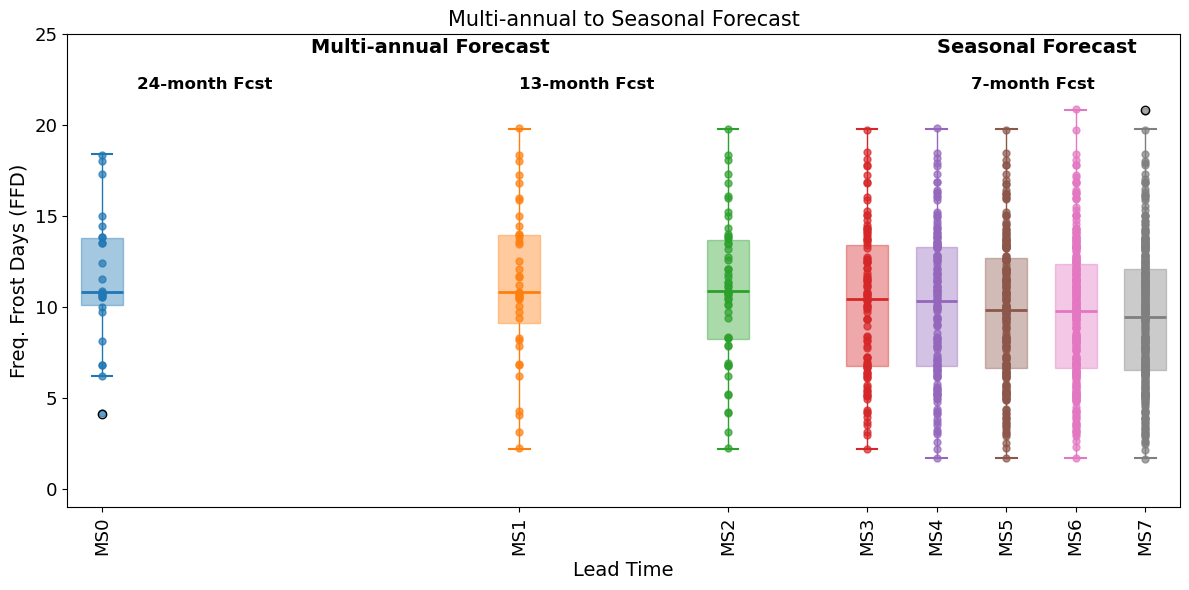

In [162]:
fig, ax = plt.subplots(figsize=(12,6))
ax.set_ylim([-1,25])

# Jitter
def jitter(y, amount=0.1):
    return y + np.random.uniform(-amount, amount, size=len(y))

# Plot each cumulative lead time
for month in df_combined2["Lead time"].unique():
    sub_df = df_combined2[df_combined2["Lead time"] == month]
    x_pos_val = x1_positions[month]
    month_color = palette_sub2.get(month, "gray")

    # Scatter plot
    ax.scatter(np.full(len(sub_df), x_pos_val),jitter(sub_df["FFDs"], amount=0.08),color=month_color,alpha=0.7,s=25)

    # Boxplot
    bp = ax.boxplot(sub_df["FFDs"].values,positions=[x_pos_val],widths=0.6,patch_artist=True)

    for box in bp['boxes']:
        box.set(facecolor=month_color,edgecolor=month_color,alpha=0.4)
    
    for whisker in bp['whiskers']:
        whisker.set(color=month_color, linewidth=1)
    
    for cap in bp['caps']:
        cap.set(color=month_color, linewidth=1.5)
 
    for median in bp['medians']:
        median.set(color=month_color, linewidth=2)

ax.set_xticks(list(x1_positions.values()))
ax.set_xticklabels(list(x1_positions.keys()), rotation=90, fontsize=13)
manage_ticks=False

ax.tick_params(axis='y', labelsize=13)
ax.set_title("Multi-annual to Seasonal Forecast", fontsize=15)
ax.set_xlabel("Lead Time", fontsize=14)
ax.set_ylabel("Freq. Frost Days (FFD)", fontsize=14)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05,1), loc='upper left')
ax.text(12, 24, 'Seasonal Forecast', fontsize = 14,color='black',rotation=0,weight='bold')
ax.text(3, 24, 'Multi-annual Forecast', fontsize = 14,color='black',rotation=0,weight='bold')
ax.text(6, 22, '13-month Fcst', fontsize = 12,color='black',rotation=0,weight='bold')
ax.text(0.5, 22, '24-month Fcst', fontsize = 12,color='black',rotation=0,weight='bold')
ax.text(12.5, 22, '7-month Fcst', fontsize = 12,color='black',rotation=0,weight='bold')

plt.tight_layout()


In [163]:
#  panel plot

In [164]:
leadtime=np.arange(22)

leadtime4=np.array([leadtime[0],leadtime[6],leadtime[12],leadtime[15],leadtime[17],leadtime[18],leadtime[19],leadtime[20],leadtime[21]])
leadtime4

array([ 0,  6, 12, 15, 17, 18, 19, 20, 21])

/tmp/user/27683/ipykernel_2385133/4193082076.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels( ('May(M-22)','Nov(M-16)', 'May(M-10)','Aug(M-7)','Oct(M-5)','Nov(M-4)','Dec(M-3)','Jan(M-2)','Feb(M-1)' ))


Text(0.2, 22, '24-month Fcst')

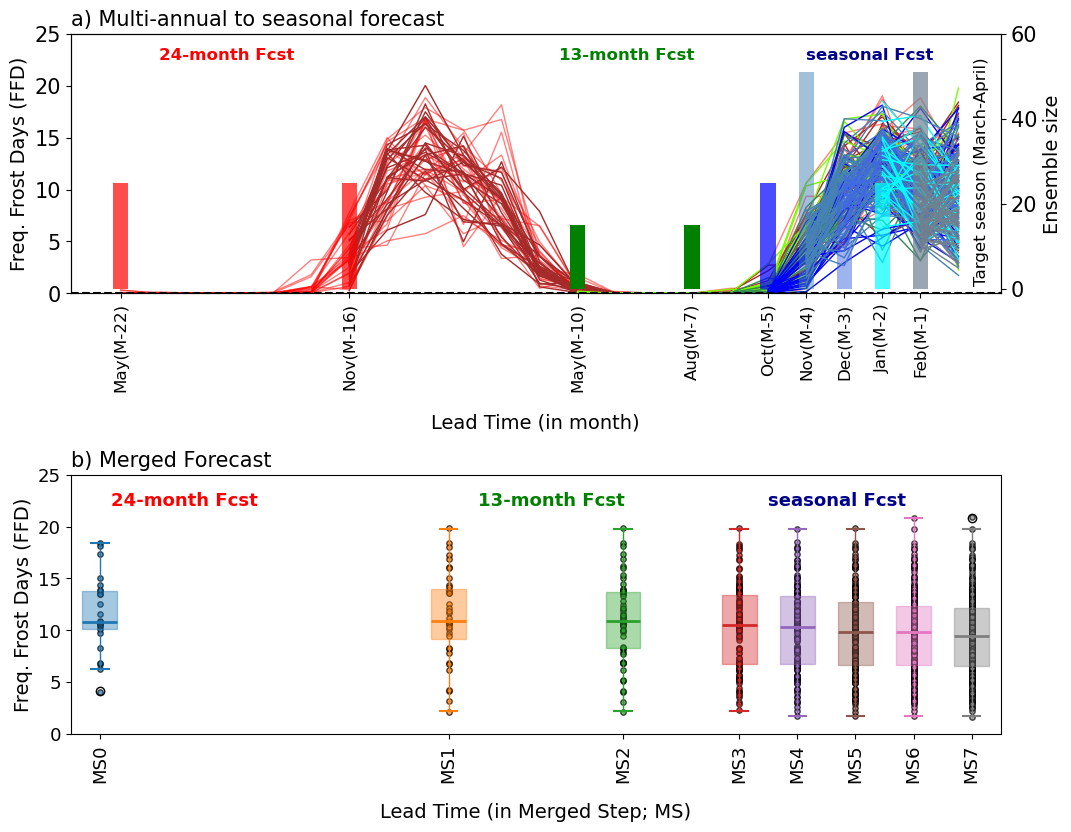

In [165]:
f,ax = plt.subplots(2,1,figsize=[12,10])
ax=ax.ravel()
f.subplots_adjust(top=0.85,bottom=0.15, hspace=0.7, wspace=0.05)

#m = np.arange(0,12)
#y2= np.arange(24,32,2)

#month1 = ['May(M-22)','Jun(M-21)','Jul(M-20)','Aug(M-19)','Sep(M-18)','Oct(M-15)','Nov(M-16)', 'Dec(M-15)','Jan(M-14) ','Feb(M-13)', 'Mar(M-12)', 'Apr(M-11)','May(M-10)','Jun(M-05)','Jul(M-06)','Aug(M-7)','Sep(M-6)','Oct(M-5)','Nov(M-4)','Dec(M-3)','Jan(M-2)','Feb(M-1)','Mar(M-0)']#,'2024-(03/04)']


ftz=15

ax[0].set_ylim([0,60])
#ax[0].tick_params(axis='x', labelrotation=90)
#month1 = ['May(M-22)','Jun(M-21)','Jul(M-20)','Aug(M-19)','Sep(M-18)','Oct(M-15)','Nov(M-16)', 'Dec(M-15)','Jan(M-14) ','Feb(M-13)', 'Mar(M-12)', 'Apr(M-11)','May(M-10)','Jun(M-05)','Jul(M-06)','Aug(M-7)','Sep(M-6)','Oct(M-5)','Nov(M-4)','Dec(M-3)','Jan(M-2)','Feb(M-1)','Mar(M-0)']#,'2024-(03/04)']
#ax[0].xaxis.set_tick_params([])


ax[0].set_xticklabels( ('May(M-22)','Nov(M-16)', 'May(M-10)','Aug(M-7)','Oct(M-5)','Nov(M-4)','Dec(M-3)','Jan(M-2)','Feb(M-1)' ))
#ax.set_xticklabels( (month1))
ax[0].set_xticks(leadtime4)
#ax[0].set_xticks([])
ax[0].tick_params(axis='x', labelrotation=90)
#ax[0].xaxis.set_tick_params(labelsize=10, rotation=90)
ax[0].yaxis.set_tick_params(labelsize=15)



#########
ax2 = ax[0].twinx()

ax[0].set_ylim([0,25])
ax[0].set_xticks(leadtime4)

#ax[1].set_xticklabels(fontsize=12)
ax[0].tick_params(axis='x', labelrotation=90)




ax[0].plot(month1,ffd_traj_mayY2[:,:],marker='o',linewidth=1,color='red',markerfacecolor='none',markersize=0,alpha=0.5)
ax[0].plot(np.arange(6,23),ffd_traj_novY2[:,:],marker='o',linewidth=1,color='brown',markerfacecolor='none',markersize=0)
ax[0].plot(np.arange(12,23),ffd_traj_mayY1[:,:],marker='o',linewidth=1,color='lawngreen',markerfacecolor='none',markersize=0)
ax[0].plot(np.arange(15,23),ffd_traj_augY1[:,:],marker='o',linewidth=1,color='seagreen',markerfacecolor='none',markersize=0)

ax[0].plot(np.arange(17,23),ffd_traj_octY1[:,0:24],marker='o',linewidth=1,color='blue',markerfacecolor='none',markersize=0)
ax[0].plot(np.arange(18,23),ffd_traj_novY1[:,:],marker='o',linewidth=1,color='steelblue',markerfacecolor='none',markersize=0)
ax[0].plot(np.arange(19,23),ffd_traj_decY1[:,0:24],marker='o',linewidth=1,color='royalblue',markerfacecolor='none',markersize=0)
ax[0].plot(np.arange(20,23),ffd_traj_janY0[:,0:24],marker='o',linewidth=1,color='aqua',markerfacecolor='none',markersize=0)
ax[0].plot(np.arange(21,23),ffd_traj_febY0[:,:],marker='o',linewidth=1,color='slategray',markerfacecolor='none',markersize=0)
#y11=ax[1].plot(np.arange(22,23),ffd_traj_marY0[:,0:24],marker='o',linewidth=0,color='navy',markerfacecolor='none',markersize=7)
#y

ax[0].set_ylabel('Freq. Frost Days (FFD)', fontsize=14)
ax[0].yaxis.set_tick_params(labelsize=15)
ax[0].xaxis.set_tick_params(labelsize=12)
ax[0].set_xlabel('Lead Time (in month)', fontsize=14, labelpad=15)

ax2.set_ylim([-1,60])

ax2.yaxis.set_tick_params(labelsize=15)

ax2.bar(leadtime[0],ensize[0],color='red',width=0.4,zorder=0,alpha=0.7)
ax2.bar(leadtime[6],ensize[1],color='red',width=0.4,zorder=0,alpha=0.7)
ax2.bar(leadtime[12], ensize[2],color='green',linestyle='solid',width=0.4)
ax2.bar(leadtime[15], ensize[3],color='green',linestyle='solid',width=0.4)

ax2.bar(leadtime[17], ensize[4],color='blue',linestyle='solid',width=0.4,alpha=0.7)
ax2.bar(leadtime[18], ensize[5],color='steelblue',linestyle='solid',width=0.4,alpha=0.5)
ax2.bar(leadtime[19], ensize[6],color='royalblue',linestyle='solid',width=0.4,alpha=0.5)
ax2.bar(leadtime[20], ensize[7],color='aqua',linestyle='solid',width=0.4,alpha=0.7)
ax2.bar(leadtime[21], ensize[8],color='slategray',linestyle='solid',width=0.4,alpha=0.7)
#ax[0].bar(leadtime[22], ensize[9],color='darkblue',linestyle='solid',width=0.4,alpha=0.6)


ax2.set_ylabel('Ensemble size', fontsize=14)


ax[0].axhline(0,linestyle='dashed',color='black')

ax[0].text(22.4, 1, 'Target season (March-April)', fontsize = 12,color='black',rotation=90)
ax[0].set_title( 'b) Ensemble Forecast (Multi-annual to month) ',fontsize=15,loc='left')



ax[0].text(18, 22.5, 'seasonal Fcst', fontsize = 12,color='darkblue',rotation=0,weight='bold')
ax[0].text(11.5, 22.5, '13-month Fcst', fontsize = 12,color='green',rotation=0,weight='bold')
ax[0].text(1, 22.5, '24-month Fcst', fontsize = 12,color='red',rotation=0,weight='bold')
#ax.text(8, 0.35, '95% significance level', fontsize = 10,color='blue')


ax[0].set_title( 'a) Multi-annual to seasonal forecast ',fontsize=15,loc='left')


############################

ax[1].set_ylim([0,25])


def jitter(y, amount=0.1):
    return y + np.random.uniform(-amount, amount, size=len(y))


for month in df_combined2["Lead time"].unique():

    sub_df = df_combined2[df_combined2["Lead time"] == month]
    x_pos_val = x1_positions[month]

    month_color = palette_sub2.get(month, "gray")
    
    # Scatter points with member-specific colors
#    point_colors = sub_df["Lead time"].map(member_colors)

#    ax[1].scatter(np.full(len(sub_df), x_pos_val),jitter(sub_df["FFDs"], amount=0.08),c=point_colors,alpha=0.7,s=25)

    # Scatter
#    ax[1].scatter(np.full(len(sub_df), x_pos_val),jitter(sub_df["FFDs"], amount=0.08),color=month_color,alpha=0.7,s=25)
    ax[1].scatter(np.full(len(sub_df), x_pos_val),jitter(sub_df["FFDs"], amount=0.08),facecolor=month_color,edgecolor='black',alpha=0.7,s=15)

    # Boxplot
    bp = ax[1].boxplot(sub_df["FFDs"].values,positions=[x_pos_val],widths=0.6,patch_artist=True)

    for box in bp['boxes']:
        box.set(facecolor=month_color,edgecolor=month_color,alpha=0.4)
    
    for whisker in bp['whiskers']:
        whisker.set(color=month_color, linewidth=1.)
    
    for cap in bp['caps']:
        cap.set(color=month_color, linewidth=1.5)
 
    for median in bp['medians']:
        median.set(color=month_color, linewidth=2)

ax[1].set_xticks(list(x1_positions.values()))
ax[1].set_xticklabels(list(x1_positions.keys()), rotation=90, fontsize=13)

manage_ticks=False

ax[1].tick_params(axis='y', labelsize=13)
#ax[2].set_title("Multi-annual to Seasonal Forecast", fontsize=15)
ax[1].set_xlabel("Lead Time (in Merged Step; MS)", fontsize=14, labelpad=15)
ax[1].set_ylabel("Freq. Frost Days (FFD)", fontsize=14)



handles, labels = ax[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05,1), loc='upper left')
#ax[1].text(12, 24, 'Seasonal Forecast', fontsize = 13,color='black',rotation=0,weight='bold')


ax[1].set_title( 'b) Merged Forecast ',fontsize=15,loc='left',color='black')



ax[1].text(11.5, 22, 'seasonal Fcst', fontsize = 13,color='darkblue',rotation=0,weight='bold')
ax[1].text(6.5, 22, '13-month Fcst', fontsize = 13,color='green',rotation=0,weight='bold')
ax[1].text(0.2, 22, '24-month Fcst', fontsize = 13,color='red',rotation=0,weight='bold')


#plt.savefig(dirfig+"FigS1_revised_manuscriptV0.png",dpi=300, bbox_inches = "tight")
